<a href="https://colab.research.google.com/github/beyzahiz/Cats-Dogs-CNN-Classifier/blob/main/Cats_Dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/cats_dogs_dataset"

train_dir = DATA_PATH + "/training_set"
test_dir = DATA_PATH + "/test_set"

Mounted at /content/drive


In [3]:
import tensorflow as tf
#tf.keras.utils.get_file() internetten dosya indirir

def get_datasets(data_dir):
    train_ds = tf.keras.utils.image_dataset_from_directory( #görselleri yükler, label atar, batch oluşturur
        data_dir,
        validation_split= 0.2,
        subset="training",
        seed=42,
        image_size=(150,150),
        batch_size=32
    )

    val_ds=tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="validation",
        seed=42,
        image_size=(150,150),
        batch_size=32
    )

    return train_ds, val_ds

In [4]:
#Data Augmentation
#Eldeki verileri hafifçe değiştirerek daha fazla veri varmış gibi çeşitlilik oluşturmak
#Data augmentation sadece training dataset’te olmalı.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"), #görseli yatayda rastgele çevirir
    layers.RandomRotation(0.1), #%10 oranında döndürür
    layers.RandomZoom(0.1), #Hafif yakınlaştırma
])


In [5]:
IMG_SIZE=(150,150)

model=keras.Sequential([
    layers.Input(shape=(150,150,3)),
    data_augmentation,
    layers.Rescaling(1./255), #normalizasyon

    #Conv
    #resmin üzerindeki featuresları yakalamaya yarar. resmin içindeki kenarları, köşeleri ve desenleri bulur.
    layers.Conv2D(32, (3,3), activation="relu"), #32 filtre sayısı, 3,3 kernel sayısı
    layers.MaxPooling2D(2,2), #resmi özetler, boyutu küçülür ama en önemli özellikler (mesela kedinin kulağının sivri ucu) korunur.

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"), #128 nöronla karmaşık kuralları öğrenir
    layers.Dropout(0.5), #modelin ezberlemesini engeller, sadece belirli nöronlara güvenmek yerine bilgiyi tüm ağa yaymayı öğrenir.
    layers.Dense(1, activation="sigmoid") #1 çıktı üretilir ve olasılığa dönüşür
])

In [6]:
model.summary()




Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
#binary_crossentropy uygulayacağım çünkü 2 sınıf var çıktı 1 tane sigmoid kullanıyorum
#categorical_crossentropy +3 sınıf varsa softmax kullanılıyorsa

train_ds, val_ds = get_datasets(train_dir)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

#Early Stopping
#model eğitimi aşamasında kullanılan callback fonksiyonu. overfitting önler
early_stop=keras.callbacks.EarlyStopping(
    monitor="val_loss", #modelin hangi değeri takip edeceği
    patience=5, #eğer val_loss değeri 5 epoch boyunca iyileşmezse eğitimi durdurur.
    restore_best_weights=True #eğitimi durdurduğunda, modelin en iyi performansı gösterdiği (hatanın en düşük olduğu) ana geri döner
)

history= model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Found 8005 files belonging to 2 classes.
Using 6404 files for training.
Found 8005 files belonging to 2 classes.
Using 1601 files for validation.
Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 718s 4s/step - accuracy: 0.5402 - loss: 0.7267 - val_accuracy: 0.6146 - val_loss: 0.6739
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 32s 160ms/step - accuracy: 0.5952 - loss: 0.6690 - val_accuracy: 0.6121 - val_loss: 0.6582
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.6191 - loss: 0.6608 - val_accuracy: 0.6334 - val_loss: 0.6749
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.6527 - loss: 0.6318 - val_accuracy: 0.6864 - val_loss: 0.5966
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 137ms/step - accuracy: 0.6773 - loss: 0.6016 - val_accuracy: 0.6839 - val_loss: 0.5985
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 138ms/step - accuracy: 0.6553 - loss: 0.6218 - val_accuracy: 0.7164 - val_loss: 0.5442
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.7

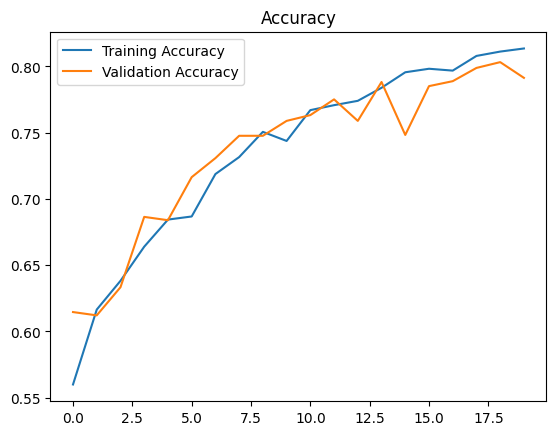

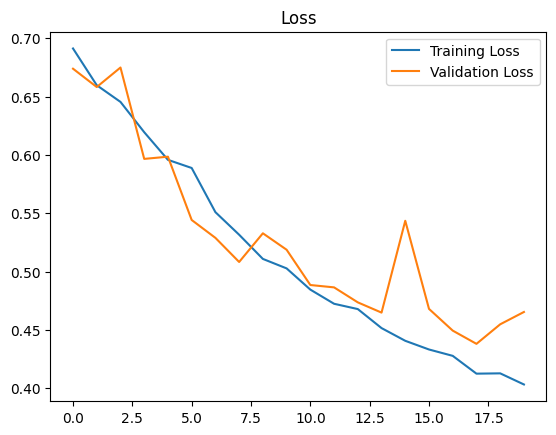

In [8]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(len(acc))

plt.figure()
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.figure()
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend()
plt.title("Loss")

plt.show()

In [9]:
#GlobalAveragePooling
#Tüm bir haritayı (kanalı) tek bir sayıya dönüştürür. Her channel için ortalama alır. Parametre düşer.

from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 32s 149ms/step - accuracy: 0.5088 - loss: 0.6939 - val_accuracy: 0.5459 - val_loss: 0.6844
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 39s 142ms/step - accuracy: 0.5576 - loss: 0.6822 - val_accuracy: 0.6071 - val_loss: 0.6639
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 142ms/step - accuracy: 0.6114 - loss: 0.6568 - val_accuracy: 0.5996 - val_loss: 0.6682
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 142ms/step - accuracy: 0.6079 - loss: 0.6568 - val_accuracy: 0.6346 - val_loss: 0.6407
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 141ms/step - accuracy: 0.6197 - loss: 0.6503 - val_accuracy: 0.5971 - val_loss: 0.6513
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 147ms/step - accuracy: 0.6399 - loss: 0.6392 - val_accuracy: 0.6546 - val_loss: 0.6240
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 141ms/step - accuracy: 0.6561 - loss: 0.6306 - val_accuracy: 0.6721 - val_loss: 0.6139
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step - accuracy: 0.6414 - loss: 0

In [21]:
#Batch Normalization
#Ağ içindeki her bir "batch" (grup) veri için şu matematiksel işlemi yapar: Verinin ortalamasını alır.
#Verinin standart sapmasını (dağılımını) hesaplar. Verileri bu değerleri kullanarak normalize eder (genellikle ortalaması 0, standart sapması 1 olacak şekilde).

model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])



In [23]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 33s 150ms/step - accuracy: 0.5725 - loss: 0.7605 - val_accuracy: 0.4916 - val_loss: 0.8035
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - accuracy: 0.5921 - loss: 0.6940 - val_accuracy: 0.5709 - val_loss: 0.6727
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - accuracy: 0.6329 - loss: 0.6509 - val_accuracy: 0.5209 - val_loss: 0.8413
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 146ms/step - accuracy: 0.6559 - loss: 0.6258 - val_accuracy: 0.5422 - val_loss: 0.7388
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - accuracy: 0.6574 - loss: 0.6159 - val_accuracy: 0.5272 - val_loss: 1.6230
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.6385 - loss: 0.6292 - val_accuracy: 0.6964 - val_loss: 0.5792
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.6827 - loss: 0.5984 - val_accuracy: 0.6558 - val_loss: 0.6091
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - accuracy: 0.6801 - loss: 0